# Hybrid Scam Detection  
### A Comparative Computational Linguistics Approach  

**ENG 685 Final Project**  
Jashona Young  

---

## Overview

This project evaluates three approaches to detecting scam and phishing language across SMS and email communication:

- Rule-based symbolic linguistic system  
- BERT-based contextual model  
- Hybrid system combining both approaches  

The goal is to compare performance, interpretability, and linguistic coverage across these frameworks, while grounding the work in symbolic computational linguistics.

Across SMS and Email Communication Contexts

This broader scope allows the analysis to capture general patterns of deceptive language rather than restricting the study to a single domain.

## 1. Introduction

Deceptive digital communication, including spam messages and phishing emails, continues to be a major challenge across modern communication platforms. These messages often rely on linguistic strategies such as urgency, impersonation, reward-based persuasion, and requests for sensitive information in order to manipulate users.

This project explores how different computational approaches can be used to detect scam and phishing language across SMS and email communication contexts. Specifically, it compares three models:

- a rule-based symbolic linguistic system  
- a BERT-based contextual model  
- a hybrid model combining both approaches  

The rule-based model focuses on explicit linguistic patterns, offering interpretability and transparency. The BERT-based model captures broader contextual meaning, allowing it to detect more subtle forms of deception. The hybrid model attempts to combine these strengths to improve overall performance.

The models are evaluated on a multi-source dataset of over 16,000 messages, including SMS spam, phishing emails, and smishing data. The goal is to compare performance, interpretability, and linguistic coverage across approaches, while highlighting the trade-offs between symbolic and neural methods in computational linguistics.

In [1]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROJECT_ROOT = Path("..").resolve()
print(PROJECT_ROOT)

/app


## 2. Data

In [3]:
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "combined_scam_dataset.csv")

df.head()

,text,label,source
0,"Go until jurong point, crazy.. Available only ...",legitimate,uci_sms_spam
1,Ok lar... Joking wif u oni...,legitimate,uci_sms_spam
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,uci_sms_spam
3,U dun say so early hor... U c already then say...,legitimate,uci_sms_spam
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,uci_sms_spam


In [4]:
df["label"].value_counts()

label
legitimate    9066
scam          7217
Name: count, dtype: int64

## 3. Preprocessing

Before analysis, text data is normalized to improve consistency across models.

Preprocessing steps include:

- converting text to lowercase
- normalizing URLs
- removing extra whitespace

This process intentionally preserves scam-relevant language patterns such as keywords, commands, and structural cues instead of aggressively removing them.

In [5]:
def basic_clean_text(text):
    """Clean text while preserving scam-relevant patterns.

    Parameters
    ----------
    text : str
        Raw input text.

    Returns
    -------
    str
        Cleaned text.
    """
    if not isinstance(text, str):
        return ""

    cleaned = text.lower()
    cleaned = re.sub(r"https?://\S+|www\.\S+", " URL ", cleaned)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()

    return cleaned

In [6]:
df["clean_text"] = df["text"].apply(basic_clean_text)

df[["text", "clean_text", "label"]]

,text,clean_text,label
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ...",legitimate
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...,legitimate
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,scam
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...,legitimate
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro...",legitimate
...,...,...,...
16278,Your monthly statement is now available in you...,your monthly statement is now available in you...,legitimate
16279,Your appointment confirmation has been updated.,your appointment confirmation has been updated.,legitimate
16280,Your package delivery status changed this morn...,your package delivery status changed this morn...,legitimate
16281,Your password was changed successfully.,your password was changed successfully.,legitimate


## 4. Rule-Based Linguistic Model

The rule-based model represents a symbolic computational linguistics approach. It uses explicitly defined linguistic patterns associated with cryptocurrency scam messages.

These include:

- urgency language
- impersonation cues
- wallet or credential requests
- guaranteed profit claims
- fear or loss framing

This model is highly interpretable because it directly shows which linguistic features triggered a classification.

In [7]:
SCAM_RULES = {
    "urgency": [
        "act now",
        "limited time",
        "last chance",
        "immediately",
        "urgent",
        "now",
        "today only",
        "expires",
        "final notice",
        "respond immediately",
    ],

    "reward_bait": [
        "congratulations",
        "you have won",
        "claim your prize",
        "free gift",
        "reward",
        "bonus",
        "selected winner",
        "cash prize",
        "gift card",
        "exclusive offer",
    ],

    "financial_manipulation": [
        "guaranteed returns",
        "risk free",
        "double your money",
        "profit guaranteed",
        "investment opportunity",
        "earn money",
        "quick cash",
        "loan approved",
        "payment failed",
        "billing information",
    ],

    "credential_request": [
        "verify your account",
        "confirm your identity",
        "reset your password",
        "update your password",
        "login now",
        "sign in",
        "account verification",
        "security check",
        "validate your account",
        "update your information",
    ],

    "impersonation_authority": [
        "official support",
        "customer support",
        "admin",
        "support agent",
        "compliance team",
        "security team",
        "fraud department",
        "account services",
        "bank notice",
        "service alert",
    ],

    "fear_loss": [
        "account suspended",
        "account locked",
        "funds at risk",
        "unauthorized activity",
        "suspicious activity",
        "avoid losing",
        "restricted account",
        "failed login attempt",
        "security alert",
        "your account will be closed",
    ],

    "action_request": [
        "click here",
        "click the link",
        "open the attachment",
        "download now",
        "call now",
        "reply stop",
        "reply yes",
        "contact us",
        "follow this link",
        "complete this form",
    ],

    "suspicious_links": [
        "http://",
        "https://",
        "www.",
        "bit.ly",
        "tinyurl",
        "shorturl",
        "t.co",
    ],
}

In [8]:
def score_with_rules(text, rules=SCAM_RULES):
    # remove cleaning here
    triggered = {}
    total_matches = 0

    for category, phrases in rules.items():
        matches = [phrase for phrase in phrases if phrase in text]

        if matches:
            triggered[category] = matches
            total_matches += len(matches)

    max_possible = sum(len(phrases) for phrases in rules.values())
    rule_score = total_matches / max_possible if max_possible else 0

    return {
        "rule_score": rule_score,
        "triggered_categories": list(triggered.keys()),
        "matched_phrases": triggered,
    }

In [9]:
rule_outputs = df["clean_text"].apply(score_with_rules)

df["rule_score"] = rule_outputs.apply(lambda output: output["rule_score"])
df["rule_triggers"] = rule_outputs.apply(lambda output: output["triggered_categories"])
df["matched_phrases"] = rule_outputs.apply(lambda output: output["matched_phrases"])

df[["clean_text", "label", "rule_score", "rule_triggers", "matched_phrases"]]

,clean_text,label,rule_score,rule_triggers,matched_phrases
0,"go until jurong point, crazy.. available only ...",legitimate,0.000000,[],{}
1,ok lar... joking wif u oni...,legitimate,0.000000,[],{}
2,free entry in 2 a wkly comp to win fa cup fina...,scam,0.000000,[],{}
3,u dun say so early hor... u c already then say...,legitimate,0.000000,[],{}
4,"nah i don't think he goes to usf, he lives aro...",legitimate,0.000000,[],{}
...,...,...,...,...,...
16278,your monthly statement is now available in you...,legitimate,0.012987,[urgency],{'urgency': ['now']}
16279,your appointment confirmation has been updated.,legitimate,0.000000,[],{}
16280,your package delivery status changed this morn...,legitimate,0.000000,[],{}
16281,your password was changed successfully.,legitimate,0.000000,[],{}


In [10]:
def rule_predict(score, threshold=0.03):
    """Predict scam or legitimate using a rule-score threshold.

    Parameters
    ----------
    score : float
        Rule-based scam score.
    threshold : float, default=0.06
        Minimum score required to classify a message as scam.

    Returns
    -------
    str
        Predicted label.
    """
    return "scam" if score >= threshold else "legitimate"


df["rule_prediction"] = df["rule_score"].apply(rule_predict)

df[["clean_text", "label", "rule_score", "rule_prediction", "rule_triggers"]]

,clean_text,label,rule_score,rule_prediction,rule_triggers
0,"go until jurong point, crazy.. available only ...",legitimate,0.000000,legitimate,[]
1,ok lar... joking wif u oni...,legitimate,0.000000,legitimate,[]
2,free entry in 2 a wkly comp to win fa cup fina...,scam,0.000000,legitimate,[]
3,u dun say so early hor... u c already then say...,legitimate,0.000000,legitimate,[]
4,"nah i don't think he goes to usf, he lives aro...",legitimate,0.000000,legitimate,[]
...,...,...,...,...,...
16278,your monthly statement is now available in you...,legitimate,0.012987,legitimate,[urgency]
16279,your appointment confirmation has been updated.,legitimate,0.000000,legitimate,[]
16280,your package delivery status changed this morn...,legitimate,0.000000,legitimate,[]
16281,your password was changed successfully.,legitimate,0.000000,legitimate,[]


In [11]:
print("Rule-Based Model Evaluation")
print(classification_report(df["label"], df["rule_prediction"], zero_division=0))

Rule-Based Model Evaluation
              precision    recall  f1-score   support

  legitimate       0.61      1.00      0.76      9066
        scam       1.00      0.19      0.32      7217

    accuracy                           0.64     16283
   macro avg       0.80      0.60      0.54     16283
weighted avg       0.78      0.64      0.56     16283



## 5. BERT-Based Contextual Model

The BERT-based model represents a machine-learned approach to language understanding.

Unlike the rule-based system, it does not rely on handcrafted scam keywords. Instead, it evaluates the full text and uses contextual relationships between words to estimate whether a message appears suspicious.

In this version, a pretrained DistilBERT model is used as a proxy baseline. This model is not specifically trained for scam detection, but it demonstrates where contextual language modeling fits in the overall pipeline.

In [12]:
from transformers import pipeline

bert_baseline = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [13]:
def bert_proxy_score(text):
    """Create a temporary scam-risk proxy score using a pretrained BERT model.

    Notes
    -----
    This is not a final scam-specific classifier. It uses a sentiment-trained
    DistilBERT model as a placeholder contextual baseline until BERT is fine-tuned
    on scam-specific text.

    Parameters
    ----------
    text : str
        Input message.

    Returns
    -------
    float
        Approximate scam-risk score between 0 and 1.
    """
    result = bert_baseline(text[:512])[0]

    label = result["label"]
    score = result["score"]

    if label == "NEGATIVE":
        return score

    return 1 - score

In [14]:
df["bert_score"] = df["text"].apply(bert_proxy_score)

df[["text", "label", "bert_score"]]

,text,label,bert_score
0,"Go until jurong point, crazy.. Available only ...",legitimate,0.991627
1,Ok lar... Joking wif u oni...,legitimate,0.991195
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,0.982790
3,U dun say so early hor... U c already then say...,legitimate,0.995092
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,0.996230
...,...,...,...
16278,Your monthly statement is now available in you...,legitimate,0.909225
16279,Your appointment confirmation has been updated.,legitimate,0.043487
16280,Your package delivery status changed this morn...,legitimate,0.992916
16281,Your password was changed successfully.,legitimate,0.000858


In [15]:
def bert_predict(score, threshold=0.50):
    """Predict scam or legitimate using the BERT proxy score.

    Parameters
    ----------
    score : float
        Approximate scam-risk score from the BERT proxy model.
    threshold : float, default=0.50
        Minimum score required to classify a message as scam.

    Returns
    -------
    str
        Predicted label.
    """
    return "scam" if score >= threshold else "legitimate"


df["bert_prediction"] = df["bert_score"].apply(bert_predict)

df[["text", "label", "bert_score", "bert_prediction"]]

,text,label,bert_score,bert_prediction
0,"Go until jurong point, crazy.. Available only ...",legitimate,0.991627,scam
1,Ok lar... Joking wif u oni...,legitimate,0.991195,scam
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,0.982790,scam
3,U dun say so early hor... U c already then say...,legitimate,0.995092,scam
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,0.996230,scam
...,...,...,...,...
16278,Your monthly statement is now available in you...,legitimate,0.909225,scam
16279,Your appointment confirmation has been updated.,legitimate,0.043487,legitimate
16280,Your package delivery status changed this morn...,legitimate,0.992916,scam
16281,Your password was changed successfully.,legitimate,0.000858,legitimate


In [16]:
print("BERT Proxy Model Evaluation")
print(classification_report(df["label"], df["bert_prediction"], zero_division=0))

BERT Proxy Model Evaluation
              precision    recall  f1-score   support

  legitimate       0.84      0.61      0.70      9066
        scam       0.63      0.85      0.73      7217

    accuracy                           0.72     16283
   macro avg       0.74      0.73      0.72     16283
weighted avg       0.75      0.72      0.71     16283



## 6. Hybrid Model

The hybrid model combines the rule-based linguistic score with the BERT-based contextual score.

This approach allows the system to benefit from:

- explicit linguistic knowledge captured in rules  
- broader contextual understanding captured by BERT  

The goal is to evaluate whether combining both approaches improves scam detection performance.

In [17]:
def hybrid_score(rule_score, bert_score, rule_weight=0.4, bert_weight=0.6):
    """Combine rule-based and BERT-based scores.

    Parameters
    ----------
    rule_score : float
        Score from rule-based model.
    bert_score : float
        Score from BERT proxy model.
    rule_weight : float
        Weight for rule-based score.
    bert_weight : float
        Weight for BERT score.

    Returns
    -------
    float
        Combined hybrid score.
    """
    return (rule_weight * rule_score) + (bert_weight * bert_score)

In [18]:
df["hybrid_score"] = df.apply(
    lambda row: hybrid_score(row["rule_score"], row["bert_score"]),
    axis=1
)

df[["text", "label", "rule_score", "bert_score", "hybrid_score"]]

,text,label,rule_score,bert_score,hybrid_score
0,"Go until jurong point, crazy.. Available only ...",legitimate,0.000000,0.991627,0.594976
1,Ok lar... Joking wif u oni...,legitimate,0.000000,0.991195,0.594717
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,0.000000,0.982790,0.589674
3,U dun say so early hor... U c already then say...,legitimate,0.000000,0.995092,0.597055
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,0.000000,0.996230,0.597738
...,...,...,...,...,...
16278,Your monthly statement is now available in you...,legitimate,0.012987,0.909225,0.550730
16279,Your appointment confirmation has been updated.,legitimate,0.000000,0.043487,0.026092
16280,Your package delivery status changed this morn...,legitimate,0.000000,0.992916,0.595750
16281,Your password was changed successfully.,legitimate,0.000000,0.000858,0.000515


In [19]:
def hybrid_predict(score, threshold=0.35):
    """Predict scam or legitimate using hybrid score."""
    return "scam" if score >= threshold else "legitimate"


df["hybrid_prediction"] = df["hybrid_score"].apply(hybrid_predict)

df[["text", "label", "hybrid_score", "hybrid_prediction"]]

,text,label,hybrid_score,hybrid_prediction
0,"Go until jurong point, crazy.. Available only ...",legitimate,0.594976,scam
1,Ok lar... Joking wif u oni...,legitimate,0.594717,scam
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,0.589674,scam
3,U dun say so early hor... U c already then say...,legitimate,0.597055,scam
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,0.597738,scam
...,...,...,...,...
16278,Your monthly statement is now available in you...,legitimate,0.550730,scam
16279,Your appointment confirmation has been updated.,legitimate,0.026092,legitimate
16280,Your package delivery status changed this morn...,legitimate,0.595750,scam
16281,Your password was changed successfully.,legitimate,0.000515,legitimate


In [20]:
print("Hybrid Model Evaluation")
print(classification_report(df["label"], df["hybrid_prediction"], zero_division=0))

Hybrid Model Evaluation
              precision    recall  f1-score   support

  legitimate       0.83      0.61      0.71      9066
        scam       0.64      0.84      0.72      7217

    accuracy                           0.72     16283
   macro avg       0.73      0.73      0.72     16283
weighted avg       0.74      0.72      0.71     16283



## 7. Evaluation

This section compares the rule-based, BERT proxy, and hybrid models using classification metrics.

The evaluation includes:

- accuracy
- precision
- recall
- F1-score
- confusion matrices
- disagreement analysis

This helps show not only which model performs best, but also where the models differ in how they classify scam language.

In [21]:
def get_metrics(y_true, y_pred, model_name):
    """Calculate classification metrics for one model.

    Parameters
    ----------
    y_true : list-like
        True labels.
    y_pred : list-like
        Predicted labels.
    model_name : str
        Name of the evaluated model.

    Returns
    -------
    dict
        Dictionary containing accuracy, precision, recall, and F1-score.
    """
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label="scam", zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label="scam", zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label="scam", zero_division=0),
    }


results = pd.DataFrame([
    get_metrics(df["label"], df["rule_prediction"], "Rule-Based"),
    get_metrics(df["label"], df["bert_prediction"], "BERT Proxy"),
    get_metrics(df["label"], df["hybrid_prediction"], "Hybrid"),
])

results.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
1,BERT Proxy,0.715716,0.632963,0.853540,0.726887
2,Hybrid,0.715777,0.635055,0.843425,0.724557
0,Rule-Based,0.641098,1.000000,0.190245,0.319674


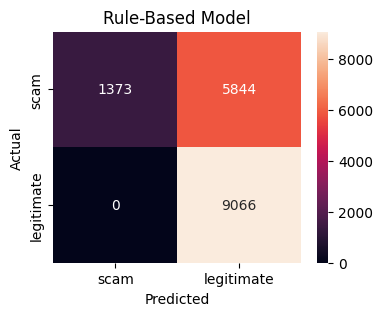

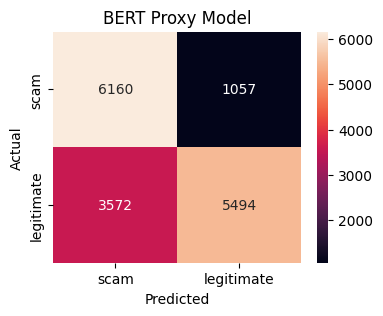

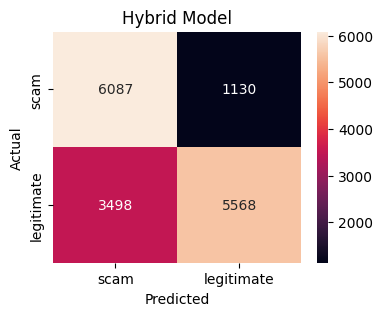

In [22]:
def plot_confusion(y_true, y_pred, title):
    """Plot a confusion matrix for scam classification results."""
    cm = confusion_matrix(y_true, y_pred, labels=["scam", "legitimate"])

    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["scam", "legitimate"],
        yticklabels=["scam", "legitimate"],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


plot_confusion(df["label"], df["rule_prediction"], "Rule-Based Model")
plot_confusion(df["label"], df["bert_prediction"], "BERT Proxy Model")
plot_confusion(df["label"], df["hybrid_prediction"], "Hybrid Model")

In [23]:
df["disagreement"] = (
    (df["rule_prediction"] != df["bert_prediction"]) |
    (df["rule_prediction"] != df["hybrid_prediction"]) |
    (df["bert_prediction"] != df["hybrid_prediction"])
)

df[df["disagreement"]][[
    "text",
    "label",
    "rule_prediction",
    "bert_prediction",
    "hybrid_prediction",
    "rule_triggers",
]]

,text,label,rule_prediction,bert_prediction,hybrid_prediction,rule_triggers
0,"Go until jurong point, crazy.. Available only ...",legitimate,legitimate,scam,scam,[]
1,Ok lar... Joking wif u oni...,legitimate,legitimate,scam,scam,[]
2,Free entry in 2 a wkly comp to win FA Cup fina...,scam,legitimate,scam,scam,[]
3,U dun say so early hor... U c already then say...,legitimate,legitimate,scam,scam,[]
4,"Nah I don't think he goes to usf, he lives aro...",legitimate,legitimate,scam,scam,[]
...,...,...,...,...,...,...
16272,call now 08707509020 Just 20p per min NTT Ltd...,scam,legitimate,scam,scam,"[urgency, action_request]"
16274,Your account has been compromised. Reset your ...,scam,legitimate,scam,scam,"[urgency, credential_request]"
16277,"Congratulations, you have won a prize. Click t...",scam,scam,legitimate,legitimate,"[reward_bait, action_request]"
16278,Your monthly statement is now available in you...,legitimate,legitimate,scam,scam,[urgency]


In [24]:
df["rule_prediction"].value_counts()
df["bert_prediction"].value_counts()
df["hybrid_prediction"].value_counts()

hybrid_prediction
scam          9585
legitimate    6698
Name: count, dtype: int64

In [25]:
results

,model,accuracy,precision,recall,f1
0,Rule-Based,0.641098,1.000000,0.190245,0.319674
1,BERT Proxy,0.715716,0.632963,0.853540,0.726887
2,Hybrid,0.715777,0.635055,0.843425,0.724557


## 8. Results and Discussion

The models were evaluated on a combined dataset of 16,283 messages drawn from multiple sources, including SMS spam, phishing emails, and smishing datasets. The dataset is relatively balanced, with 9,066 legitimate messages and 7,217 scam messages, allowing for meaningful comparison across models.

The rule-based model achieved an accuracy of 0.64, with perfect precision (1.00) but low recall (0.19), resulting in an F1-score of 0.32. This indicates that while the model is highly reliable when it identifies a scam, it fails to detect a large portion of scam messages. This behavior reflects the limitations of rule-based systems, which rely on explicit linguistic cues and struggle with variations or paraphrased forms of deceptive language.

The BERT-based model significantly improves recall, achieving 0.85 recall and an F1-score of approximately 0.73, with an overall accuracy of 0.72. This demonstrates its ability to capture contextual patterns beyond predefined keywords. However, its precision drops to approximately 0.63, indicating that it produces a higher number of false positives. This suggests that the model may interpret neutral or informal language as suspicious due to its reliance on general sentiment patterns rather than task-specific training.

The hybrid model produces results similar to the BERT model, with an accuracy of approximately 0.72 and an F1-score of 0.72. It achieves a recall of 0.84 while slightly improving precision compared to the BERT model. This indicates that combining rule-based and contextual signals can help balance detection performance. However, the hybrid model does not significantly outperform the BERT model, suggesting that the contribution of the rule-based component is limited when combined with a strong contextual model.

Disagreement analysis further highlights differences between the approaches. A substantial number of messages were classified differently across models, demonstrating that rule-based and contextual systems capture distinct aspects of deceptive language. In particular, the rule-based model tends to miss scams that lack explicit keywords, while the BERT model may overgeneralize and classify benign messages as scams.

Overall, the results demonstrate that symbolic and neural approaches provide complementary strengths. While rule-based systems offer interpretability and precision, contextual models provide broader coverage. The hybrid approach illustrates the potential of combining these methods, but also highlights the need for more sophisticated integration strategies.

## 9. Limitations

This project has several limitations that should be considered when interpreting the results.

First, although the dataset is larger and more diverse than the initial version, it is constructed from multiple public sources with varying labeling standards. This may introduce inconsistencies in how scam and legitimate messages are defined across datasets.

Second, the BERT model used in this project is not fine-tuned for scam detection. It is a pretrained sentiment classification model, which contributes to false positives and limits its ability to fully capture domain-specific patterns of deception.

Third, the rule-based system relies on manually defined linguistic patterns. While this approach achieves perfect precision in this experiment, its low recall (0.19) demonstrates that it fails to capture many scam messages that do not match predefined patterns.

Additionally, the hybrid model, while improving recall and maintaining balanced performance, does not significantly outperform the BERT model. This suggests that simple weighted combinations may not be sufficient to fully leverage the strengths of both symbolic and neural approaches.

Future work could address these limitations by:

- fine-tuning transformer-based models on scam-specific datasets  
- expanding and standardizing the dataset to reduce labeling inconsistencies  
- incorporating more advanced ensemble methods or stacking techniques  
- refining rule-based features using deeper linguistic analysis, such as discourse structure and pragmatics  

These improvements would enhance both the accuracy and robustness of the system in real-world applications.